<a href="https://colab.research.google.com/github/vhousos/EKPA/blob/main/chousos_ids_ips.ipynb" target="_parent"><img src="https://colab.research.google.com/assets/colab-badge.svg" alt="Open In Colab"/></a>

General Imports

In [ ]:
import os
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt

from sklearn.model_selection import train_test_split
from sklearn.preprocessing import MinMaxScaler
from sklearn.utils import class_weight
from sklearn.metrics import confusion_matrix, ConfusionMatrixDisplay

import tensorflow as tf
from tensorflow.keras.models import Sequential
from tensorflow.keras.layers import Dense, Dropout
from tensorflow.keras.callbacks import ModelCheckpoint, EarlyStopping
from tensorflow.keras.utils import to_categorical




Load the csv file from Mr Demertzis github repository, and analyze the available headers. Separate features/labels - MIN/MAX normalization - Define Test, Train and Validation data

In [ ]:
def loadDataset():
    filename = "https://raw.githubusercontent.com/kdemertzis/EKPA/main/Data/pcap_data.csv"
    df = pd.read_csv(filename)
    df.head()

    X = df.drop('target', axis=1).to_numpy().astype('float32')
    y = df['target'].to_numpy().astype('int32')

    # Min-Max scaling
    scaler = MinMaxScaler()
    X_scaled = scaler.fit_transform(X)

    # Test data 20%
    train_data, test_data, train_label, test_label = train_test_split(
        X_scaled, y,
        test_size=0.20,
        stratify=y,
        random_state=42
    )

    # Train 70%, Validation 10% (0.125 * 80% ≈ 10% συνολικά)
    train_data, val_data, train_label, val_label = train_test_split(
        train_data, train_label,
        test_size=0.125,
        stratify=train_label,
        random_state=42
    )

    return (
        train_data.astype('float32'),
        train_label.astype('int32'),
        val_data.astype('float32'),
        val_label.astype('int32'),
        test_data.astype('float32'),
        test_label.astype('int32')
    )

Define the Dense Model - Load Data - simple Dense Neural Network for 3-class classification and load the preprocessed dataset.

In [ ]:
from sklearn.model_selection import train_test_split

def build_dense_model(input_dim, n_classes=3, lr=1e-3):
    """
    Δημιουργεί ένα απλό Dense νευρωνικό δίκτυο για ταξινόμηση 3 κλάσεων.
    """
    model = Sequential()
    model.add(Dense(128, activation='relu', input_shape=(input_dim,)))
    model.add(Dropout(0.3))
    model.add(Dense(64, activation='relu'))
    model.add(Dropout(0.3))
    model.add(Dense(n_classes, activation='softmax'))

    model.compile(
        optimizer=tf.keras.optimizers.Adam(learning_rate=lr),
        loss='categorical_crossentropy',
        metrics=['accuracy']
    )
    return model


train_data, train_labelp, val_data, val_labelp, test_data, test_labelp = loadDataset()

Transform to one-hot  - Class balancing weghts - Callbacks

In [ ]:
from sklearn.preprocessing import StandardScaler

nclass = 3
train_label = to_categorical(train_labelp, nclass)
val_label   = to_categorical(val_labelp,   nclass)
test_label  = to_categorical(test_labelp,  nclass)

print('train_data.shape=', train_data.shape)
print('test_data.shape=',  test_data.shape)
print('val_data.shape=',   val_data.shape)

# get the number of features
inshape = train_data.shape[1]





class_weights_raw = class_weight.compute_class_weight(
    class_weight='balanced',
    classes=np.unique(train_labelp),
    y=train_labelp
)
class_weights = {i: class_weights_raw[i] for i in range(len(class_weights_raw))}
print("class_weights:", class_weights)






os.makedirs('./savemodels', exist_ok=True)

earlyStopping = EarlyStopping(
    monitor='val_loss',
    patience=20,
    verbose=1,
    mode='min',
    restore_best_weights=True
)

modelCheckPoint = ModelCheckpoint(
    filepath='./savemodels/model_pcap_best.{epoch:03d}-{val_accuracy:.4f}.h5',
    save_best_only=True,
    monitor='val_accuracy',
    mode='max',
    verbose=1
)

train_data.shape= (10476, 25)
test_data.shape= (2994, 25)
val_data.shape= (1497, 25)
class_weights: {0: np.float64(0.9974293059125964), 1: np.float64(0.9954389965792474), 2: np.float64(1.007210845111047)}


Create and train the model - Load the best model from "savedmodels"

In [ ]:
epochs = 100
batch_size = 256

model = build_dense_model(input_dim=inshape, n_classes=nclass, lr=1e-3)
model.summary()

history = model.fit(
    train_data, train_label,
    shuffle=True,
    epochs=epochs,
    batch_size=batch_size,
    validation_data=(val_data, val_label),
    class_weight=class_weights,
    callbacks=[modelCheckPoint, earlyStopping]
)



str_models = os.listdir('./savemodels')
str_models = np.sort(str_models)
best_model = str_models[-1]
print('best_model =', best_model)

model.load_weights('./savemodels/' + best_model)


/usr/local/lib/python3.12/dist-packages/keras/src/layers/core/dense.py:93: UserWarning: Do not pass an `input_shape`/`input_dim` argument to a layer. When using Sequential models, prefer using an `Input(shape)` object as the first layer in the model instead.
  super().__init__(activity_regularizer=activity_regularizer, **kwargs)


Model: "sequential"

┏━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━━━━┓
┃ Layer (type)                    ┃ Output Shape           ┃       Param # ┃
┡━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━━━━┩
│ dense (Dense)                   │ (None, 128)            │         3,328 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dropout (Dropout)               │ (None, 128)            │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dense_1 (Dense)                 │ (None, 64)             │         8,256 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dropout_1 (Dropout)             │ (None, 64)             │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dense_2 (Dense)                 │ (None, 3)              │           195 │
└─────────────────────────────────┴────────────────────────┴───────────────┘

 Total params: 11,779 (46.01 KB)

 Trainable params: 11,779 (46.01 KB)

...

41/41 ━━━━━━━━━━━━━━━━━━━━ 0s 9ms/step - accuracy: 0.9044 - loss: 0.3589 - val_accuracy: 0.9018 - val_loss: 0.3902
Epoch 70/100
39/41 ━━━━━━━━━━━━━━━━━━━━ 0s 4ms/step - accuracy: 0.9086 - loss: 0.3510
Epoch 70: val_accuracy did not improve from 0.90180
41/41 ━━━━━━━━━━━━━━━━━━━━ 1s 6ms/step - accuracy: 0.9086 - loss: 0.3511 - val_accuracy: 0.8991 - val_loss: 0.3892
Epoch 71/100
38/41 ━━━━━━━━━━━━━━━━━━━━ 0s 4ms/step - accuracy: 0.9101 - loss: 0.3432
Epoch 71: val_accuracy did not improve from 0.90180
41/41 ━━━━━━━━━━━━━━━━━━━━ 0s 7ms/step - accuracy: 0.9100 - loss: 0.3439 - val_accuracy: 0.8971 - val_loss: 0.3905
Epoch 72/100
36/41 ━━━━━━━━━━━━━━━━━━━━ 0s 6ms/step - accuracy: 0.9112 - loss: 0.3394
Epoch 72: val_accuracy did not improve from 0.90180
41/41 ━━━━━━━━━━━━━━━━━━━━ 0s 8ms/step - accuracy: 0.9107 - loss: 0.3411 - val_accuracy: 0.8971 - val_loss: 0.3923
Epoch 73/100
39/41 ━━━━━━━━━━━━━━━━━━━━ 0s 4ms/step - accuracy: 0.9081 - loss: 0.3455
Epoch 73: val_accuracy improved from 0.9

41/41 ━━━━━━━━━━━━━━━━━━━━ 0s 7ms/step - accuracy: 0.9081 - loss: 0.3458 - val_accuracy: 0.9025 - val_loss: 0.3892
Epoch 74/100
36/41 ━━━━━━━━━━━━━━━━━━━━ 0s 4ms/step - accuracy: 0.9085 - loss: 0.3477
Epoch 74: val_accuracy did not improve from 0.90247
41/41 ━━━━━━━━━━━━━━━━━━━━ 0s 7ms/step - accuracy: 0.9085 - loss: 0.3480 - val_accuracy: 0.8998 - val_loss: 0.3884
Epoch 75/100
34/41 ━━━━━━━━━━━━━━━━━━━━ 0s 5ms/step - accuracy: 0.9132 - loss: 0.3362
Epoch 75: val_accuracy did not improve from 0.90247
41/41 ━━━━━━━━━━━━━━━━━━━━ 0s 8ms/step - accuracy: 0.9126 - loss: 0.3387 - val_accuracy: 0.9005 - val_loss: 0.3919
Epoch 76/100
38/41 ━━━━━━━━━━━━━━━━━━━━ 0s 4ms/step - accuracy: 0.9071 - loss: 0.3456
Epoch 76: val_accuracy did not improve from 0.90247
41/41 ━━━━━━━━━━━━━━━━━━━━ 0s 6ms/step - accuracy: 0.9071 - loss: 0.3461 - val_accuracy: 0.8965 - val_loss: 0.3904
Epoch 77/100
36/41 ━━━━━━━━━━━━━━━━━━━━ 0s 4ms/step - accuracy: 0.9089 - loss: 0.3383
Epoch 77: val_accuracy did not improve f

41/41 ━━━━━━━━━━━━━━━━━━━━ 0s 8ms/step - accuracy: 0.9140 - loss: 0.3394 - val_accuracy: 0.9031 - val_loss: 0.3865
Epoch 80/100
39/41 ━━━━━━━━━━━━━━━━━━━━ 0s 6ms/step - accuracy: 0.9128 - loss: 0.3465
Epoch 80: val_accuracy did not improve from 0.90314
41/41 ━━━━━━━━━━━━━━━━━━━━ 0s 8ms/step - accuracy: 0.9127 - loss: 0.3467 - val_accuracy: 0.9018 - val_loss: 0.3886
Epoch 81/100
33/41 ━━━━━━━━━━━━━━━━━━━━ 0s 5ms/step - accuracy: 0.9061 - loss: 0.3477
Epoch 81: val_accuracy did not improve from 0.90314
41/41 ━━━━━━━━━━━━━━━━━━━━ 0s 8ms/step - accuracy: 0.9067 - loss: 0.3461 - val_accuracy: 0.8991 - val_loss: 0.3891
Epoch 82/100
34/41 ━━━━━━━━━━━━━━━━━━━━ 0s 5ms/step - accuracy: 0.9059 - loss: 0.3491
Epoch 82: val_accuracy did not improve from 0.90314
41/41 ━━━━━━━━━━━━━━━━━━━━ 0s 7ms/step - accuracy: 0.9064 - loss: 0.3481 - val_accuracy: 0.8958 - val_loss: 0.3915
Epoch 83/100
34/41 ━━━━━━━━━━━━━━━━━━━━ 0s 5ms/step - accuracy: 0.9051 - loss: 0.3661
Epoch 83: val_accuracy did not improve f

41/41 ━━━━━━━━━━━━━━━━━━━━ 0s 9ms/step - accuracy: 0.9111 - loss: 0.3504 - val_accuracy: 0.9038 - val_loss: 0.3882
Epoch 88/100
41/41 ━━━━━━━━━━━━━━━━━━━━ 0s 6ms/step - accuracy: 0.9113 - loss: 0.3490
Epoch 88: val_accuracy did not improve from 0.90381
41/41 ━━━━━━━━━━━━━━━━━━━━ 0s 9ms/step - accuracy: 0.9113 - loss: 0.3488 - val_accuracy: 0.8998 - val_loss: 0.3911
Epoch 89/100
34/41 ━━━━━━━━━━━━━━━━━━━━ 0s 5ms/step - accuracy: 0.9040 - loss: 0.3479
Epoch 89: val_accuracy did not improve from 0.90381
41/41 ━━━━━━━━━━━━━━━━━━━━ 0s 8ms/step - accuracy: 0.9045 - loss: 0.3482 - val_accuracy: 0.9025 - val_loss: 0.3846
Epoch 90/100
32/41 ━━━━━━━━━━━━━━━━━━━━ 0s 7ms/step - accuracy: 0.9160 - loss: 0.3312
Epoch 90: val_accuracy did not improve from 0.90381
41/41 ━━━━━━━━━━━━━━━━━━━━ 0s 9ms/step - accuracy: 0.9156 - loss: 0.3322 - val_accuracy: 0.9005 - val_loss: 0.3905
Epoch 91/100
37/41 ━━━━━━━━━━━━━━━━━━━━ 0s 6ms/step - accuracy: 0.9051 - loss: 0.3583
Epoch 91: val_accuracy did not improve f

41/41 ━━━━━━━━━━━━━━━━━━━━ 1s 13ms/step - accuracy: 0.9113 - loss: 0.3453 - val_accuracy: 0.9051 - val_loss: 0.3850
Epoch 97/100
35/41 ━━━━━━━━━━━━━━━━━━━━ 0s 8ms/step - accuracy: 0.9168 - loss: 0.3160
Epoch 97: val_accuracy did not improve from 0.90514
41/41 ━━━━━━━━━━━━━━━━━━━━ 0s 10ms/step - accuracy: 0.9162 - loss: 0.3192 - val_accuracy: 0.9005 - val_loss: 0.3843
Epoch 98/100
36/41 ━━━━━━━━━━━━━━━━━━━━ 0s 5ms/step - accuracy: 0.9142 - loss: 0.3341
Epoch 98: val_accuracy did not improve from 0.90514
41/41 ━━━━━━━━━━━━━━━━━━━━ 0s 7ms/step - accuracy: 0.9141 - loss: 0.3344 - val_accuracy: 0.8931 - val_loss: 0.3943
Epoch 99/100
39/41 ━━━━━━━━━━━━━━━━━━━━ 0s 5ms/step - accuracy: 0.9162 - loss: 0.3325
Epoch 99: val_accuracy did not improve from 0.90514
41/41 ━━━━━━━━━━━━━━━━━━━━ 0s 8ms/step - accuracy: 0.9160 - loss: 0.3328 - val_accuracy: 0.9031 - val_loss: 0.3842
Epoch 100/100
34/41 ━━━━━━━━━━━━━━━━━━━━ 0s 5ms/step - accuracy: 0.9112 - loss: 0.3414
Epoch 100: val_accuracy did not impro

Confusion matrix to "test" set - Plotting the confusion matrix

TEST DATA - Confusion matrix:
94/94 ━━━━━━━━━━━━━━━━━━━━ 0s 2ms/step
[[879  72  50]
 [ 38 922  43]
 [ 41  23 926]]
Accuracy ratios for each class
Normal (0) = 0.8781
Anomaly (1) = 0.9192
Attack (2) = 0.9354


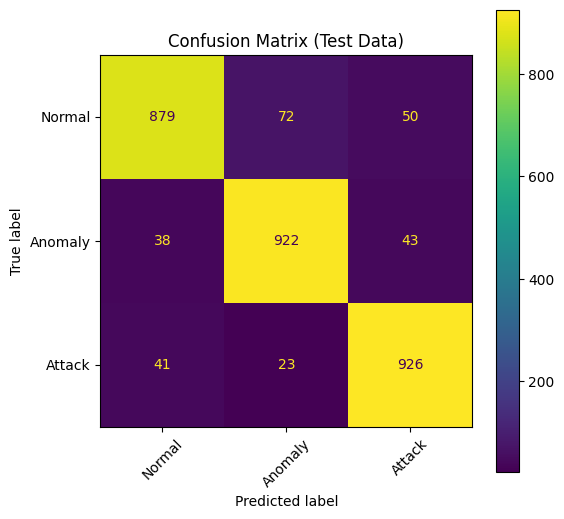

In [ ]:
print('TEST DATA - Confusion matrix:')

pred = model.predict(test_data)
pred_y = np.argmax(pred, axis=1)

cm = confusion_matrix(test_labelp.astype('int32'), pred_y)
print(cm)

print('Accuracy ratios for each class')
for i, cls_name in enumerate(['Normal (0)', 'Anomaly (1)', 'Attack (2)']):
    acc_i = cm[i, i] / np.sum(cm[i, :])
    print(f'{cls_name} = {acc_i:.4f}')





label_names = np.array(['Normal', 'Anomaly', 'Attack'])

cmo = ConfusionMatrixDisplay(cm, display_labels=label_names)
fig, ax = plt.subplots(figsize=(6, 6))
cmo.plot(ax=ax, xticks_rotation=45)
plt.title('Confusion Matrix (Test Data)')
plt.show()

Convert IDS predictions into preventive IPS actions (allow, alert, block).

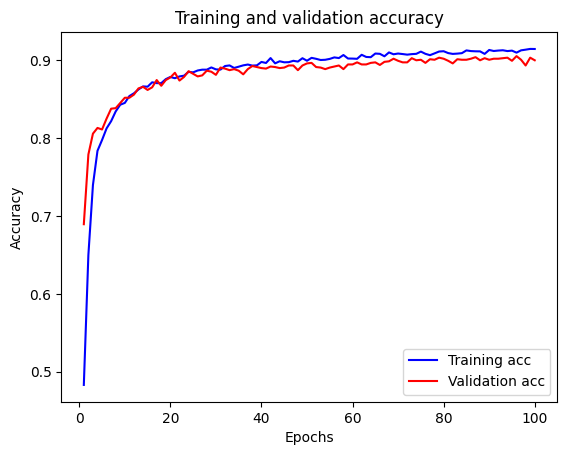

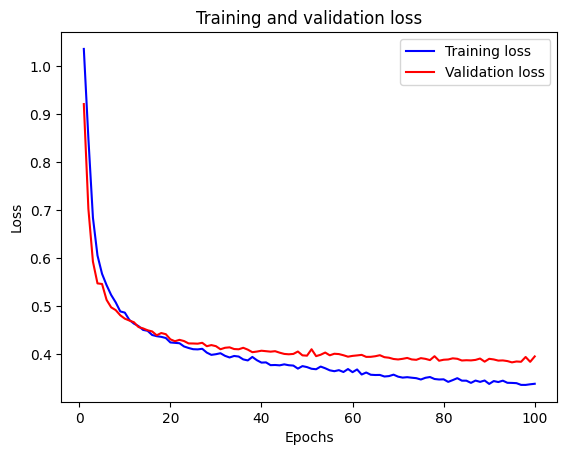

In [ ]:
# === IPS Decision Engine ===

def ips_decision_engine(predicted_class):
    """
    Μετατρέπει την πρόβλεψη του IDS σε ενέργεια IPS.
    0 = Normal  → ALLOW
    1 = Anomaly → ALERT_AND_MONITOR
    2 = Attack  → BLOCK_AND_NOTIFY
    """
    if predicted_class == 0:
        return "ALLOW"
    elif predicted_class == 1:
        return "ALERT_AND_MONITOR"
    elif predicted_class == 2:
        return "BLOCK_AND_NOTIFY"
    else:
        return "UNKNOWN"


Apply IPS Decisions on Test Data

In [ ]:
print("\nIPS DECISIONS ON TEST DATA\n")

ips_actions = []

for i in range(len(test_data)):
    cls = pred_y[i]
    action = ips_decision_engine(cls)
    ips_actions.append(action)
    print(f"Flow {i:04d}: Pred={cls} → Action={action}")


updating the model online based on newly observed attacks (idea taken from OnlineLearning_IPS Mr. Demertzis's file)

In [ ]:
# === Online learning component (optional) ===

def online_learning_update(model, feature_vector, true_label):
    """
    Ενημερώνει το μοντέλο με νέο δείγμα – προσομοίωση online learning IPS.
    """
    fv = feature_vector.reshape(1, -1)
    lbl = to_categorical(np.array([true_label]), 3)
    model.fit(fv, lbl, epochs=1, verbose=0)


# Example: update only on detected attacks
for i in range(len(test_data)):
    if pred_y[i] == 2:   # Attack
        online_learning_update(model, test_data[i], pred_y[i])
